# MILK10k — Exploratory Data Analysis

Course project — Computer Vision and Speech Recognition (EADA).

Dataset: 10,480 images from 5,240 lesions (dermoscopic + clinical close-up pairs).


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../data/raw/milk10k")
IMG_DIR  = DATA_DIR / "images"
SUPP_DIR = DATA_DIR / "supplements"
FIG_DIR  = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Data dir exists  :", DATA_DIR.exists())
print("Images dir exists:", IMG_DIR.exists())
print("Number of image files:", len(list(IMG_DIR.glob("*.jpg"))))


Data dir exists  : True
Images dir exists: True
Number of image files: 10480


In [2]:
meta = pd.read_csv(DATA_DIR / "metadata.csv")
gt   = pd.read_csv(SUPP_DIR / "training_gt.csv")
inp  = pd.read_csv(SUPP_DIR / "training_input.csv")
sup  = pd.read_csv(SUPP_DIR / "training_supp.csv")

print("metadata       :", meta.shape)
print("training_gt    :", gt.shape)
print("training_input :", inp.shape)
print("training_supp  :", sup.shape)


metadata       : (10480, 17)
training_gt    : (5240, 12)
training_input : (10480, 17)
training_supp  : (10480, 4)


In [3]:
display(meta.head(3))
display(gt.head(3))
print("\nmetadata columns:", list(meta.columns))
print("gt columns      :", list(gt.columns))
print("\nUnique lesions in metadata :", meta["lesion_id"].nunique())
print("Unique images in metadata  :", meta["isic_id"].nunique())
print("\nImages per lesion (should all be 2):")
print(meta.groupby("lesion_id").size().value_counts())


,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,concomitant_biopsy,diagnosis_1,diagnosis_2,diagnosis_3,diagnosis_4,diagnosis_confirm_type,image_manipulation,image_type,lesion_id,melanocytic,sex
0,ISIC_0051817,MILK study team,CC-BY-NC,70.0,upper extremity,NaN,True,Malignant,Malignant epidermal proliferations,"Squamous cell carcinoma, Invasive",NaN,histopathology,instrument only,dermoscopic,IL_1612768,NaN,male
1,ISIC_0073863,MILK study team,CC-BY-NC,5.0,NaN,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Reed",histopathology,instrument only,dermoscopic,IL_2547802,True,female
2,ISIC_0075884,MILK study team,CC-BY-NC,10.0,upper extremity,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Acral",histopathology,instrument only,clinical: close-up,IL_9270970,True,female


,lesion_id,AKIEC,BCC,BEN_OTH,BKL,DF,INF,MAL_OTH,MEL,NV,SCCKA,VASC
0,IL_0000652,0,1,0,0,0,0,0,0,0,0,0
1,IL_0003176,0,1,0,0,0,0,0,0,0,0,0
2,IL_0004688,0,1,0,0,0,0,0,0,0,0,0



metadata columns: ['isic_id', 'attribution', 'copyright_license', 'age_approx', 'anatom_site_general', 'anatom_site_special', 'concomitant_biopsy', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4', 'diagnosis_confirm_type', 'image_manipulation', 'image_type', 'lesion_id', 'melanocytic', 'sex']
gt columns      : ['lesion_id', 'AKIEC', 'BCC', 'BEN_OTH', 'BKL', 'DF', 'INF', 'MAL_OTH', 'MEL', 'NV', 'SCCKA', 'VASC']

Unique lesions in metadata : 5240
Unique images in metadata  : 10480

Images per lesion (should all be 2):
2    5240
Name: count, dtype: int64


In [4]:
cols = ["age_approx","sex","anatom_site_general","diagnosis_1","diagnosis_2","image_type","attribution","image_manipulation"]
print("Fraction missing:\n", meta[cols].isna().mean().sort_values(ascending=False))
print("\nSex (per image):\n", meta["sex"].value_counts(dropna=False))
print("\nAnatomic site (per lesion):")
print(meta.drop_duplicates("lesion_id")["anatom_site_general"].value_counts(dropna=False).head(12))
print("\nImage types:\n", meta["image_type"].value_counts())

# Skin tone viene en training_input.csv — lo mostramos aquí
skin_tone = inp.drop_duplicates("lesion_id")["skin_tone_class"].value_counts().sort_index()
print("\nSkin tone (per lesion, from training_input.csv):")
print(skin_tone)


Fraction missing:
 anatom_site_general    0.373282
age_approx             0.003817
sex                    0.000000
diagnosis_1            0.000000
diagnosis_2            0.000000
image_type             0.000000
attribution            0.000000
image_manipulation     0.000000
dtype: float64

Sex (per image):
 sex
male      6304
female    4176
Name: count, dtype: int64

Anatomic site (per lesion):
anatom_site_general
NaN                1956
head/neck          1491
lower extremity    1046
upper extremity     739
oral/genital          8
Name: count, dtype: int64

Image types:
 image_type
dermoscopic           5240
clinical: close-up    5240
Name: count, dtype: int64

Skin tone (per lesion, from training_input.csv):
skin_tone_class
0       6
1     105
2     506
3    3174
4    1066
5     383
Name: count, dtype: int64


Top-level diagnosis_1 (per lesion):
 diagnosis_1
Malignant        3634
Benign           1483
Indeterminate     123
Name: count, dtype: int64

11-class counts (per lesion):
 class
BCC        2522
NV          746
BKL         544
SCCKA       473
MEL         450
AKIEC       303
DF           52
INF          50
VASC         47
BEN_OTH      44
MAL_OTH       9
Name: count, dtype: int64


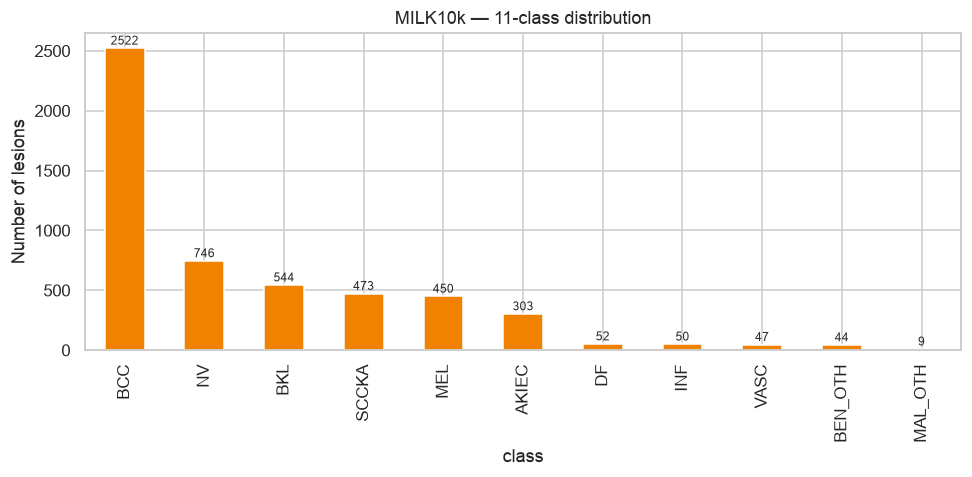

In [5]:
dx1 = meta.drop_duplicates("lesion_id")["diagnosis_1"].value_counts()
print("Top-level diagnosis_1 (per lesion):\n", dx1)

gt_long = (gt.set_index("lesion_id").stack().loc[lambda s: s == 1].reset_index()[["lesion_id","level_1"]].rename(columns={"level_1":"class"}))
class_counts = gt_long["class"].value_counts()
print("\n11-class counts (per lesion):\n", class_counts)

fig, ax = plt.subplots(figsize=(9, 4.5))
class_counts.plot(kind="bar", ax=ax, color="#F08200")
ax.set_ylabel("Number of lesions")
ax.set_title("MILK10k — 11-class distribution")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 30, str(v), ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution_11.png", dpi=150, bbox_inches="tight")
plt.show()


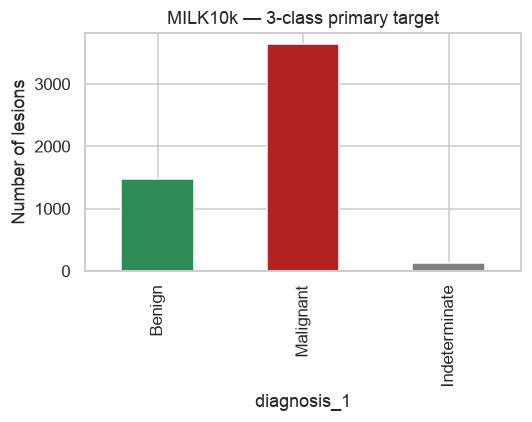

In [6]:
dx1_plot = dx1.reindex(["Benign","Malignant","Indeterminate"]).dropna()
fig, ax = plt.subplots(figsize=(5, 4))
dx1_plot.plot(kind="bar", ax=ax, color=["#2E8B57","#B22222","#808080"])
ax.set_ylabel("Number of lesions")
ax.set_title("MILK10k — 3-class primary target")
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution_3.png", dpi=150, bbox_inches="tight")
plt.show()


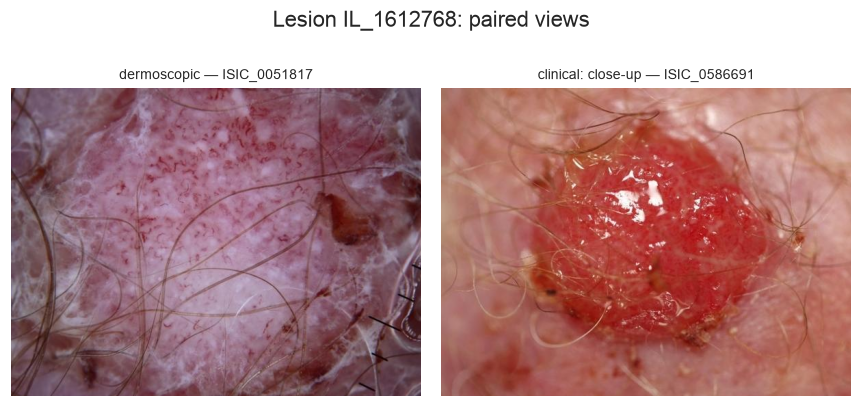

In [7]:
example_id = meta["lesion_id"].value_counts().index[0]
pair = meta[meta["lesion_id"] == example_id]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (_, row) in zip(axes, pair.iterrows()):
    img = Image.open(IMG_DIR / f'{row["isic_id"]}.jpg').convert("RGB")
    ax.imshow(img)
    ax.set_title(f'{row["image_type"]} — {row["isic_id"]}', fontsize=9)
    ax.axis("off")
plt.suptitle(f"Lesion {example_id}: paired views")
plt.tight_layout()
plt.savefig(FIG_DIR / "lesion_pair_example.png", dpi=150, bbox_inches="tight")
plt.show()


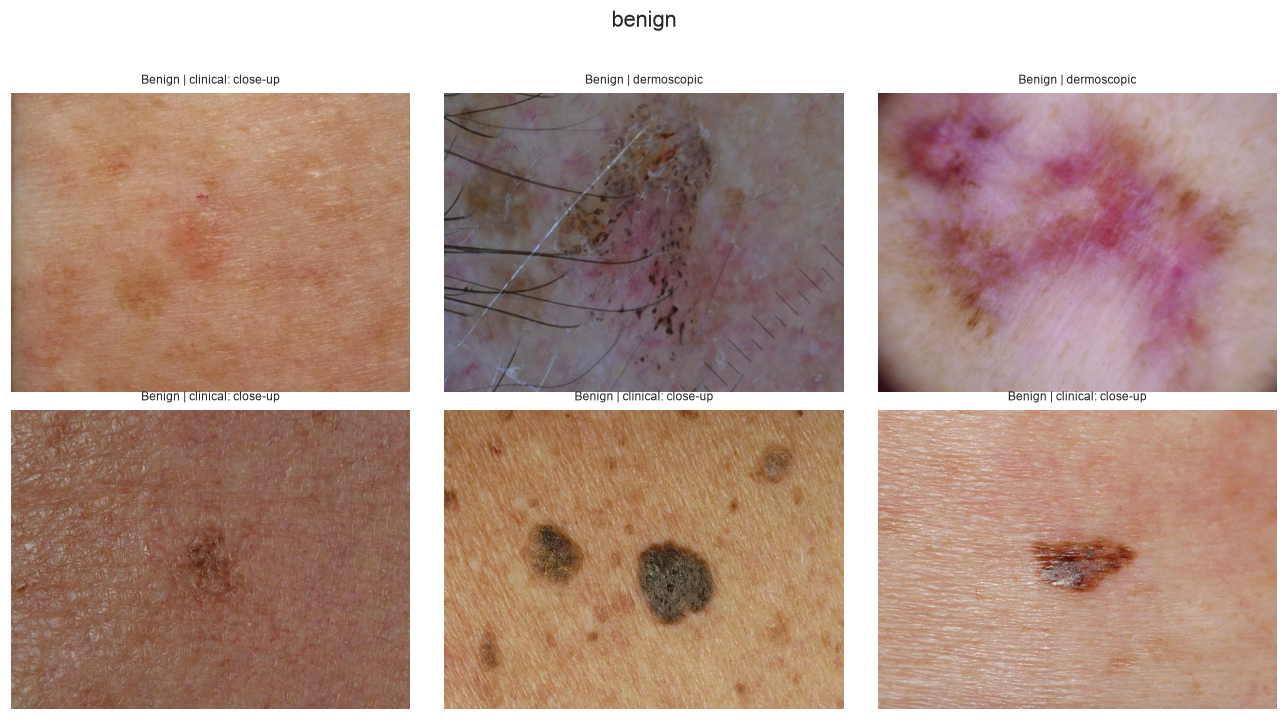

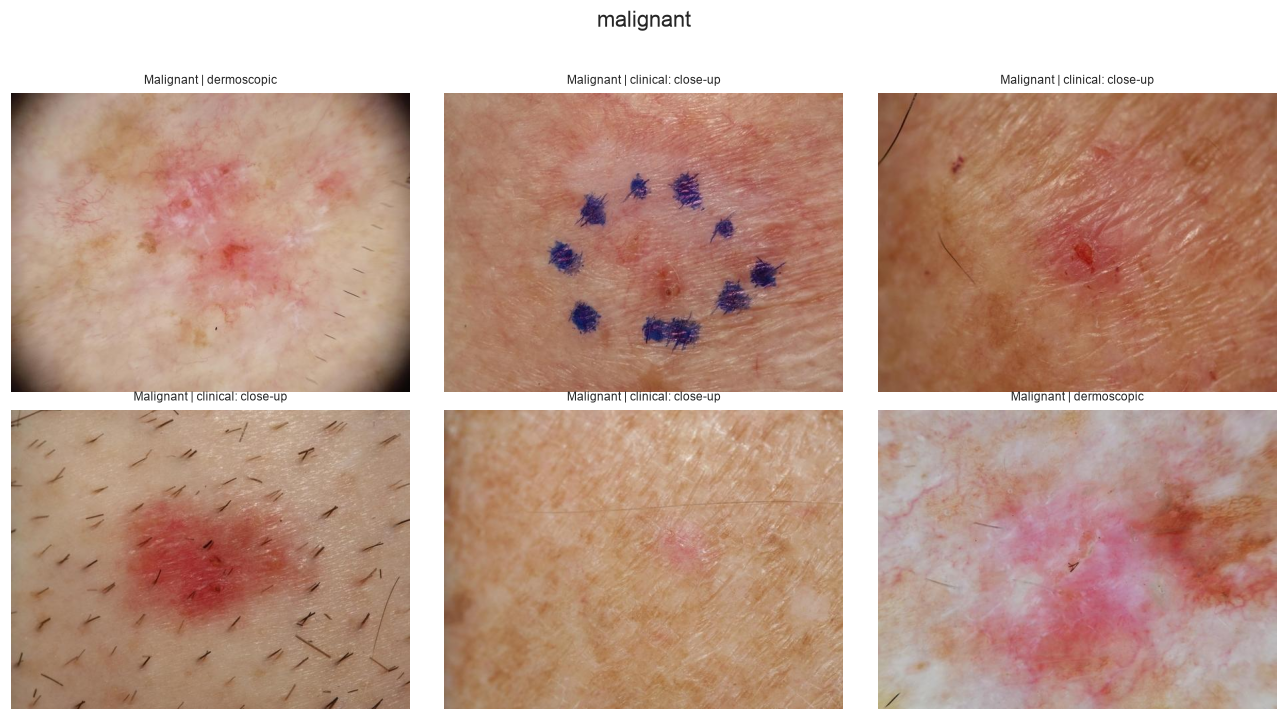

In [8]:
def show_samples(df, n=6, title="", seed=0):
    sample = df.sample(min(n, len(df)), random_state=seed)
    cols = min(3, n); rows = int(np.ceil(len(sample)/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3.2*rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(IMG_DIR / f'{row["isic_id"]}.jpg').convert("RGB")
        ax.imshow(img)
        ax.set_title(f'{row["diagnosis_1"]} | {row.get("image_type","")}', fontsize=8)
        ax.axis("off")
    for ax in axes[len(sample):]: ax.axis("off")
    plt.suptitle(title, y=1.02); plt.tight_layout()
    plt.savefig(FIG_DIR / f"sample_{title}.png", dpi=150, bbox_inches="tight")
    plt.show()

show_samples(meta[meta["diagnosis_1"] == "Benign"],    n=6, title="benign")
show_samples(meta[meta["diagnosis_1"] == "Malignant"], n=6, title="malignant")


  0%|          | 0/200 [00:00<?, ?it/s]

Avg width  : 600.0 ± 0.0
Avg height : 450.0 ± 0.0
Width range : 600 – 600
Height range: 450 – 450
Modes: {'RGB': 200}


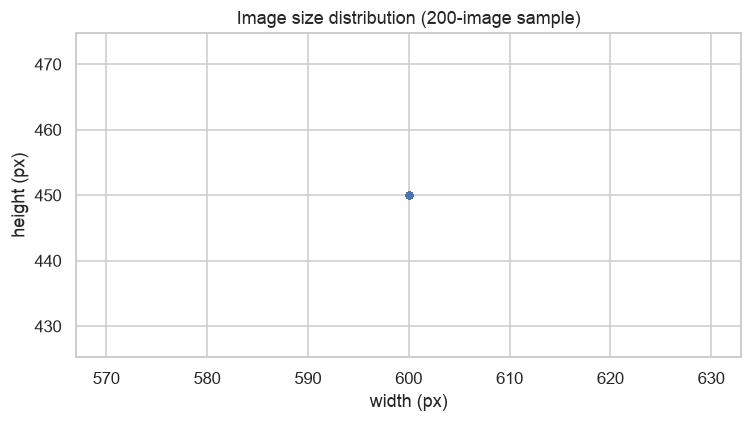

In [9]:
sample = meta.sample(200, random_state=0)
widths, heights, modes = [], [], []
for _, row in tqdm(sample.iterrows(), total=len(sample)):
    with Image.open(IMG_DIR / f'{row["isic_id"]}.jpg') as im:
        w, h = im.size
        widths.append(w); heights.append(h); modes.append(im.mode)

print(f"Avg width  : {np.mean(widths):.1f} ± {np.std(widths):.1f}")
print(f"Avg height : {np.mean(heights):.1f} ± {np.std(heights):.1f}")
print(f"Width range : {min(widths)} – {max(widths)}")
print(f"Height range: {min(heights)} – {max(heights)}")
print("Modes:", pd.Series(modes).value_counts().to_dict())

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(widths, heights, alpha=0.5, s=15)
ax.set_xlabel("width (px)"); ax.set_ylabel("height (px)")
ax.set_title("Image size distribution (200-image sample)")
plt.tight_layout()
plt.savefig(FIG_DIR / "image_sizes.png", dpi=150, bbox_inches="tight")
plt.show()


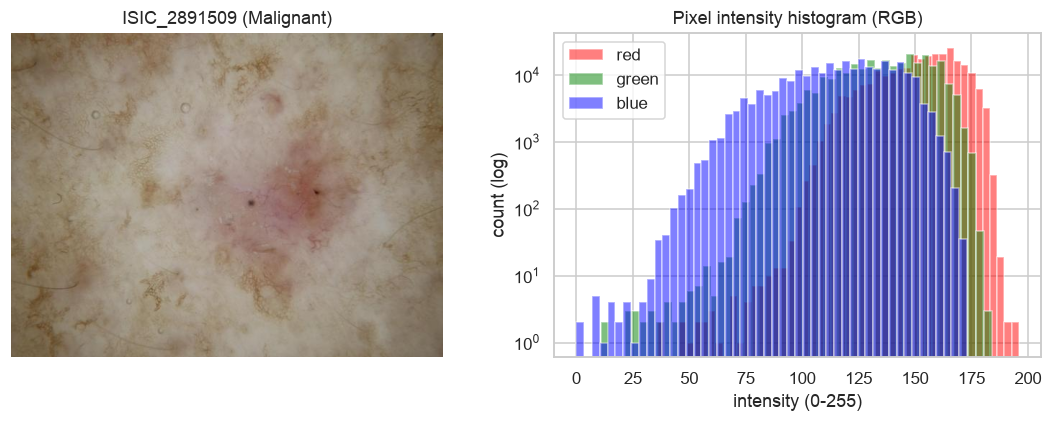

In [10]:
row = meta.sample(1, random_state=0).iloc[0]
arr = np.array(Image.open(IMG_DIR / f'{row["isic_id"]}.jpg').convert("RGB"))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(arr)
axes[0].set_title(f'{row["isic_id"]} ({row["diagnosis_1"]})'); axes[0].axis("off")
for c, color in zip(range(3), ["red","green","blue"]):
    axes[1].hist(arr[..., c].ravel(), bins=50, color=color, alpha=0.5, label=color, log=True)
axes[1].set_title("Pixel intensity histogram (RGB)")
axes[1].set_xlabel("intensity (0-255)"); axes[1].set_ylabel("count (log)")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "pixel_histogram.png", dpi=150, bbox_inches="tight")
plt.show()


Merged shape: (10480, 32)
MONET columns: ['MONET_ulceration_crust', 'MONET_hair', 'MONET_vasculature_vessels', 'MONET_erythema', 'MONET_pigmented', 'MONET_gel_water_drop_fluid_dermoscopy_liquid', 'MONET_skin_markings_pen_ink_purple_pen']


,MONET_ulceration_crust,MONET_hair,MONET_vasculature_vessels,MONET_erythema,MONET_pigmented,MONET_gel_water_drop_fluid_dermoscopy_liquid,MONET_skin_markings_pen_ink_purple_pen
diagnosis_1,,,,,,,
Benign,0.313,0.298,0.075,0.265,0.480,0.226,0.304
Indeterminate,0.347,0.273,0.083,0.303,0.313,0.251,0.164
Malignant,0.380,0.275,0.141,0.395,0.244,0.251,0.215


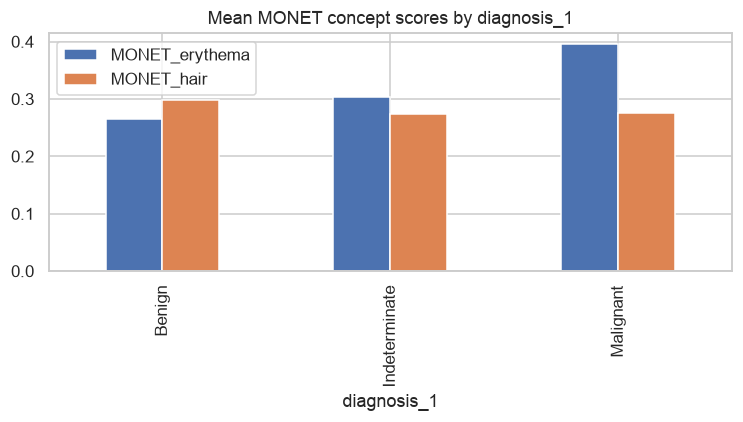

In [11]:
merged = inp.merge(meta, on=["lesion_id","isic_id"], suffixes=("","_meta"))
print("Merged shape:", merged.shape)
monet_cols = [c for c in merged.columns if c.startswith("MONET_")]
print("MONET columns:", monet_cols)
summary = merged.groupby("diagnosis_1")[monet_cols].mean().round(3)
display(summary)
summary[["MONET_erythema","MONET_hair"]].plot(kind="bar", figsize=(7,4), title="Mean MONET concept scores by diagnosis_1")
plt.tight_layout()
plt.savefig(FIG_DIR / "monet_by_diagnosis.png", dpi=150, bbox_inches="tight")
plt.show()


## Key EDA takeaways

1. **Structure:** 5,240 lesions x 2 images = 10,480 images (dermoscopic + clinical). Splits MUST group by `lesion_id`.
2. **Imbalance:** 11-class distribution dominated by BCC and NV; MEL is a minority -> use class weights, macro-F1, per-class recall.
3. **Metadata:** age, sex, skin tone (6 levels), site are unevenly distributed -> report subgroup metrics (fairness).
4. **Images:** variable resolution, RGB, uint8 -> standardize + normalize.
5. **Shortcuts:** hair, rulers, ink marks, gel — model can cheat. MONET scores help diagnose this.
6. **Two views:** clinical + dermoscopy. Try both, then fuse.
